<a href="https://colab.research.google.com/github/faraz2134/CNN_BRAIN_TUMOUR/blob/main/Brain_Tumour_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls "/content/drive/MyDrive"

'2CSED1G3 ECOURT MANAGEMENT SYSTEM.docx'
 446d2a3a-669a-4ac7-9302-800b45aa07c3.docx
 9b090f86-caa1-42fa-83d9-4497705ad08c.docx
'archive (1).zip'
 Classroom
'Colab Notebooks'
'Digital-Domination-Tactics-for-online-business-and-product-promotion (1).gslides'
 IMG-20250730-WA0015.jpg
 IMG-20250730-WA0016.jpg
 IMG_20251121_124021.jpg
 IMG-20251203-WA0002.jpg
 OSPRESEN.gslides
'RenderCV_EngineeringResumes_Theme (1) (1) (1).pdf'
'RenderCV_EngineeringResumes_Theme (1) (1) (2).pdf'
'RenderCV_EngineeringResumes_Theme (1) (1) (3).pdf'
'RenderCV_EngineeringResumes_Theme (1) (1).pdf'
'Rishikesh Trip'
 Screenshot_20250730_123937.jpg
 Screenshot_20251121_123839.jpg
'sleeping barber.gslides'
'sleeping barber.pdf'
'Untitled presentation (1).gslides'
'Untitled presentation.gslides'


In [ ]:
!unzip -q "/content/drive/MyDrive/archive (1).zip"

In [ ]:
import os
print(os.listdir())

['.config', 'Training', 'drive', 'Testing', 'sample_data']


In [ ]:
import tensorflow as tf

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'Training',
    image_size=(224,224),
    batch_size=32
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    'Testing',
    image_size=(224,224),
    batch_size=32
)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(train_ds, validation_data=test_ds, epochs=5)

Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 75ms/step - accuracy: 0.6039 - loss: 1.4460 - val_accuracy: 0.7219 - val_loss: 0.7973
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.9009 - loss: 0.2830 - val_accuracy: 0.8294 - val_loss: 0.7559
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.9651 - loss: 0.1017 - val_accuracy: 0.8494 - val_loss: 0.7766
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - accuracy: 0.9849 - loss: 0.0485 - val_accuracy: 0.8462 - val_loss: 0.9830
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.9917 - loss: 0.0284 - val_accuracy: 0.8619 - val_loss: 1.1515


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(4, activation='softmax')
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 36s 97ms/step - accuracy: 0.4951 - loss: 1.4601 - val_accuracy: 0.6925 - val_loss: 0.8217
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.7545 - loss: 0.6478 - val_accuracy: 0.7444 - val_loss: 0.8114
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.7963 - loss: 0.5622 - val_accuracy: 0.7650 - val_loss: 0.8213
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - accuracy: 0.8184 - loss: 0.4859 - val_accuracy: 0.7638 - val_loss: 0.8582
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 72ms/step - accuracy: 0.8387 - loss: 0.4262 - val_accuracy: 0.7750 - val_loss: 0.8213
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.8501 - loss: 0.4078 - val_accuracy: 0.7781 - val_loss: 0.8169
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.8539 - loss: 0.3808 - val_accuracy: 0.7869 - val_loss: 0.7894
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.8570 - loss: 0.3700 - 

In [ ]:
model.evaluate(test_ds)

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.8041 - loss: 0.7737


[0.7852104306221008, 0.7987499833106995]

In [ ]:
base_model.trainable = False

In [ ]:
base_model.trainable = True

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # VERY LOW
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
for layer in base_model.layers[:-20]:
    layer.trainable = False

In [ ]:
history_fine = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 25s 93ms/step - accuracy: 0.7900 - loss: 0.5906 - val_accuracy: 0.7937 - val_loss: 0.8030
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 87ms/step - accuracy: 0.8274 - loss: 0.4714 - val_accuracy: 0.7837 - val_loss: 0.8873
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 87ms/step - accuracy: 0.8602 - loss: 0.3779 - val_accuracy: 0.8019 - val_loss: 0.8417
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - accuracy: 0.8661 - loss: 0.3615 - val_accuracy: 0.8100 - val_loss: 0.7987
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - accuracy: 0.8782 - loss: 0.3245 - val_accuracy: 0.8250 - val_loss: 0.7645


In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 85ms/step - accuracy: 0.8833 - loss: 0.3005 - val_accuracy: 0.8288 - val_loss: 0.7405
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 86ms/step - accuracy: 0.9026 - loss: 0.2742 - val_accuracy: 0.8369 - val_loss: 0.7222
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 88ms/step - accuracy: 0.8963 - loss: 0.2714 - val_accuracy: 0.8413 - val_loss: 0.6999
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 86ms/step - accuracy: 0.9042 - loss: 0.2503 - val_accuracy: 0.8444 - val_loss: 0.6966
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step - accuracy: 0.9135 - loss: 0.2338 - val_accuracy: 0.8487 - val_loss: 0.6527
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 83ms/step - accuracy: 0.9115 - loss: 0.2404 - val_accuracy: 0.8519 - val_loss: 0.6341
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - accuracy: 0.9156 - loss: 0.2199 - val_accuracy: 0.8525 - val_loss: 0.6252
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 85ms/step - accuracy: 0.9299 - loss: 0.1959 - 

In [ ]:
model.fit(train_ds, validation_data=test_ds, epochs=5)

Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - accuracy: 0.9285 - loss: 0.1975 - val_accuracy: 0.8506 - val_loss: 0.6206
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 86ms/step - accuracy: 0.9198 - loss: 0.2042 - val_accuracy: 0.8612 - val_loss: 0.5995
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 85ms/step - accuracy: 0.9214 - loss: 0.1946 - val_accuracy: 0.8594 - val_loss: 0.6026
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 84ms/step - accuracy: 0.9304 - loss: 0.1779 - val_accuracy: 0.8531 - val_loss: 0.6269
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 15s 84ms/step - accuracy: 0.9376 - loss: 0.1547 - val_accuracy: 0.8581 - val_loss: 0.6200


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.3),
    tf.keras.layers.RandomZoom(0.3),
    tf.keras.layers.RandomContrast(0.3)
])

In [ ]:
class_weight = {0:1, 1:1, 2:1, 3:1}  # adjust if needed

In [ ]:
base_model = tf.keras.applications.ResNet50(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


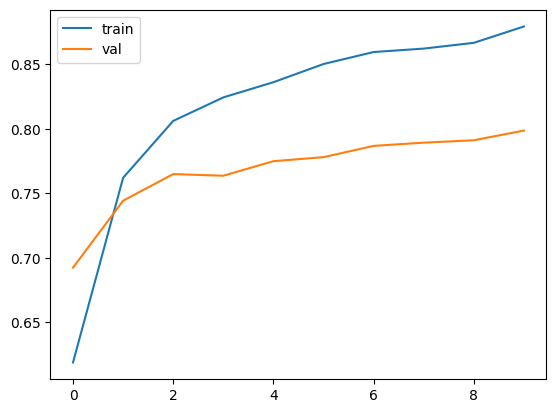

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()

In [ ]:
model.evaluate(test_ds)

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.8635 - loss: 0.6018


[0.6200122237205505, 0.8581249713897705]

In [ ]:
class_names = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


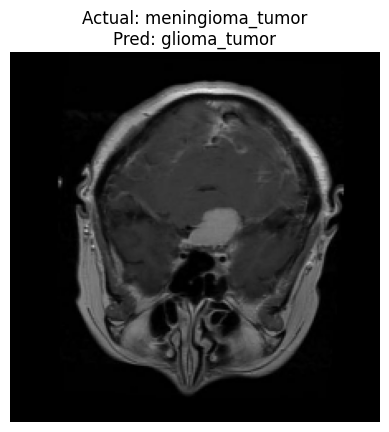

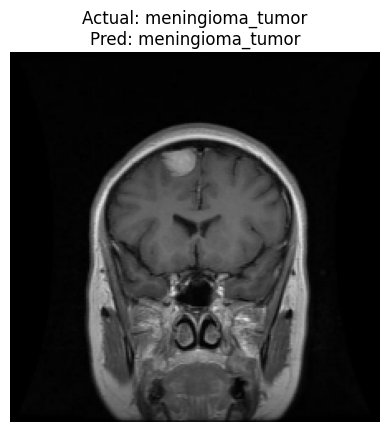

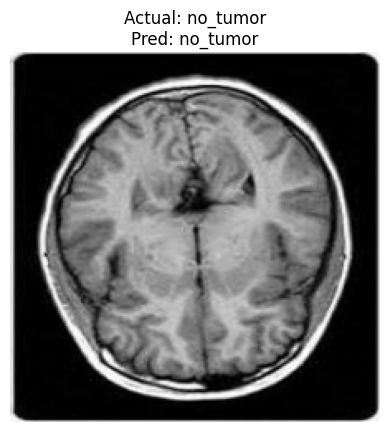

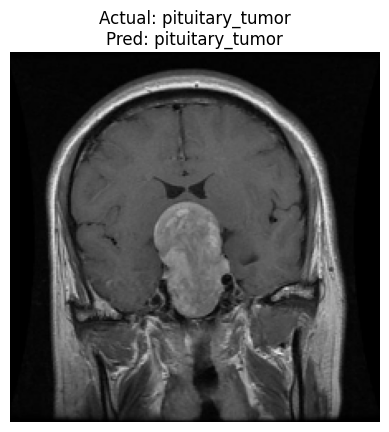

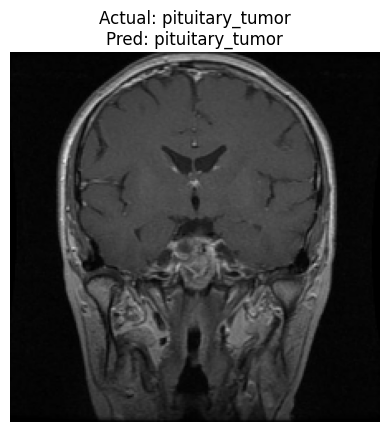

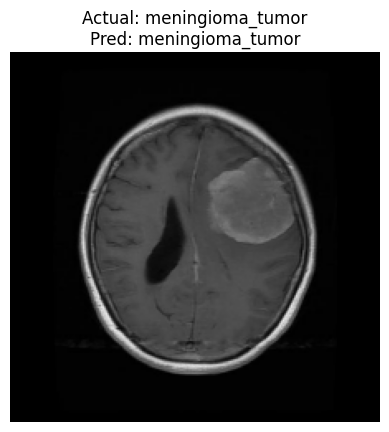

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# FIX: define class names manually
class_names = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

for images, labels in test_ds.take(1):
    preds = model.predict(images)

    for i in range(6):
        plt.imshow(images[i].numpy().astype("uint8"))

        actual = class_names[labels[i].numpy()]   # FIX
        predicted = class_names[np.argmax(preds[i])]

        plt.title(f"Actual: {actual}\nPred: {predicted}")
        plt.axis('off')
        plt.show()

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/s

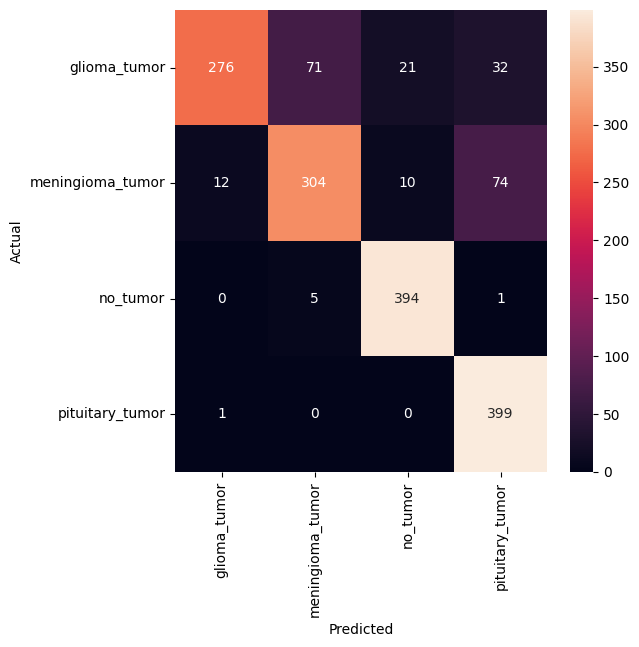

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
model.save("brain_tumor_model.h5")

In [ ]:
model.save("brain_tumor_model.keras")

In [ ]:
from google.colab import files
files.download("brain_tumor_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("brain_tumor_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>